# EDA — OASIS-3 Final Cohort
### Final dataset analysis: demographic characterisation of the CN/AD cohort
**Mondragon Unibertsitatea · 2025/2026**

---
This notebook analyses the **final filtered cohort** (`OASIS3_metadata_final.csv`).  
It covers class distribution, age, sex, education and their relationships —
building the demographic picture of the dataset used for DL model training.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
                     'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.3,'font.size':11})

PALETTE = {'CN': '#2196F3', 'AD': '#F44336'}
DPI     = 150


## 2. Load & overview

In [2]:
df = pd.read_csv('OASIS3_metadata_final.csv')
df['Group'] = df['DEMENTED'].map({0: 'CN', 1: 'AD'})
df['Sex']   = df['Gender'].map({1: 'Male', 2: 'Female'})

CN = df[df['Group'] == 'CN']
AD = df[df['Group'] == 'AD']

print(f'Subjects : {len(df)}  (CN={len(CN)}, AD={len(AD)})')
print(f'Variables: {df.shape[1]}')
print(f'Missing  : {df.isnull().sum().sum()}')
df.head(8)


Subjects : 1086  (CN=686, AD=400)
Variables: 9
Missing  : 0


,Subject_ID,Session_ID,DEMENTED,NORMCOG,Age,Gender,Education,Group,Sex
0,OAS30001,d0129,0,1,65.54,2,12.0,CN,Female
1,OAS30002,d0653,0,1,69.04,1,18.0,CN,Male
2,OAS30003,d0558,0,1,60.34,2,18.0,CN,Female
3,OAS30004,d1101,0,1,58.14,2,17.0,CN,Female
4,OAS30005,d0581,0,1,49.65,2,16.0,CN,Female
5,OAS30006,d1308,0,1,65.71,1,16.0,CN,Male
6,OAS30007,d0061,1,0,71.76,1,18.0,AD,Male
7,OAS30008,d0061,0,1,52.51,2,12.0,CN,Female


## 3. Missing values

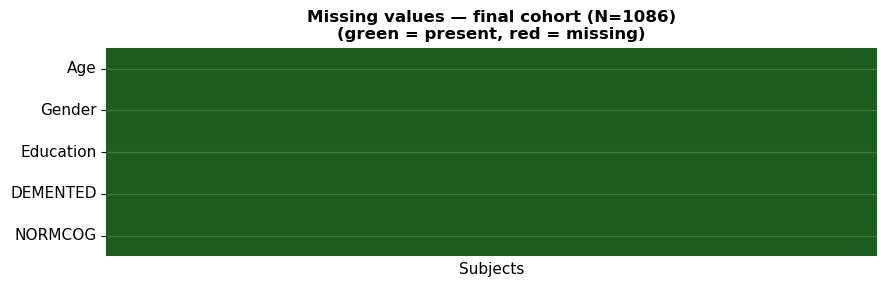

Missing values per column:
Age          0
Gender       0
Education    0
DEMENTED     0
NORMCOG      0

✓ No missing values — no imputation required.


In [3]:
fig, ax = plt.subplots(figsize=(9, 3))

null_mat = df[['Age','Gender','Education','DEMENTED','NORMCOG']].isnull()
sns.heatmap(null_mat.T, cbar=False, cmap=['#1B5E20','#F44336'],
            xticklabels=False, ax=ax, linewidths=0)
ax.set_title(f'Missing values — final cohort (N={len(df)})\n(green = present, red = missing)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Subjects')
plt.tight_layout()
plt.show()

print('Missing values per column:')
print(df[['Age','Gender','Education','DEMENTED','NORMCOG']].isnull().sum().to_string())
print('\n✓ No missing values — no imputation required.')


## 4. Class distribution

The final cohort contains 686 CN and 400 AD subjects, yielding a CN:AD ratio of 1.7:1.
This moderate imbalance justifies the use of **F1-score** as the primary evaluation
metric for the DL models (Section 6.3.1).


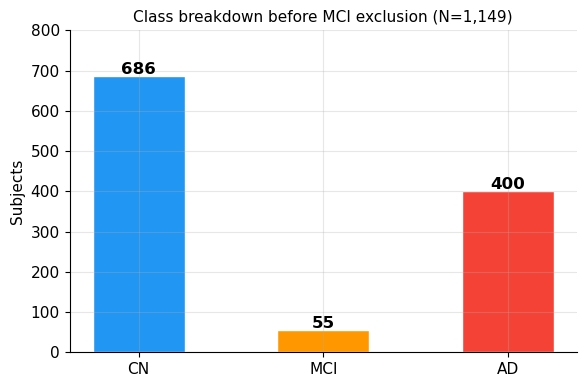

In [4]:
mci_before = {'CN': 686, 'MCI': 55, 'AD': 400}

fig, ax = plt.subplots(figsize=(6, 4))

colors = ['#2196F3', '#FF9800', '#F44336']
bars = ax.bar(mci_before.keys(), mci_before.values(),
              color=colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, mci_before.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(v), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Class breakdown before MCI exclusion (N=1,149)', fontsize=11)
ax.set_ylabel('Subjects'); ax.set_ylim(0, 800)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

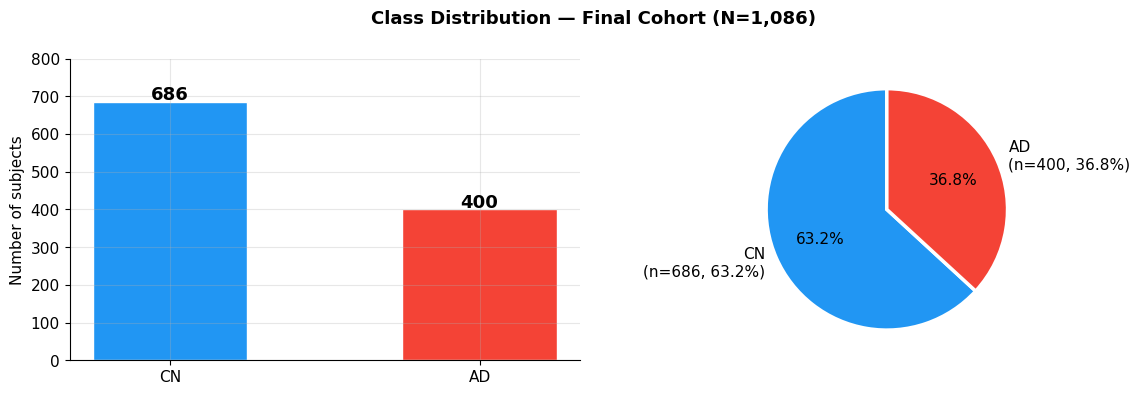

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Class Distribution — Final Cohort (N=1,086)', fontsize=13, fontweight='bold')

# Bar
counts = df['Group'].value_counts().reindex(['CN','AD'])
bars = axes[0].bar(['CN','AD'], counts.values,
                   color=[PALETTE['CN'], PALETTE['AD']],
                   edgecolor='white', width=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 str(v), ha='center', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of subjects')
axes[0].set_ylim(0, 800)

# Pie
axes[1].pie(counts.values,
            labels=[f'CN\n(n=686, 63.2%)', f'AD\n(n=400, 36.8%)'],
            colors=[PALETTE['CN'], PALETTE['AD']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2.5},
            textprops={'fontsize':11})

plt.tight_layout()
plt.show()


## 5. Age analysis

The AD group is significantly older than CN (75.9 vs 67.3 years, p < 0.001).
Since intracortical myelin naturally declines with age, this difference is a critical
confound that must be controlled before comparing myelin maps between groups.
This is the key justification for the **age-matching** procedure in Section 6.2.1.


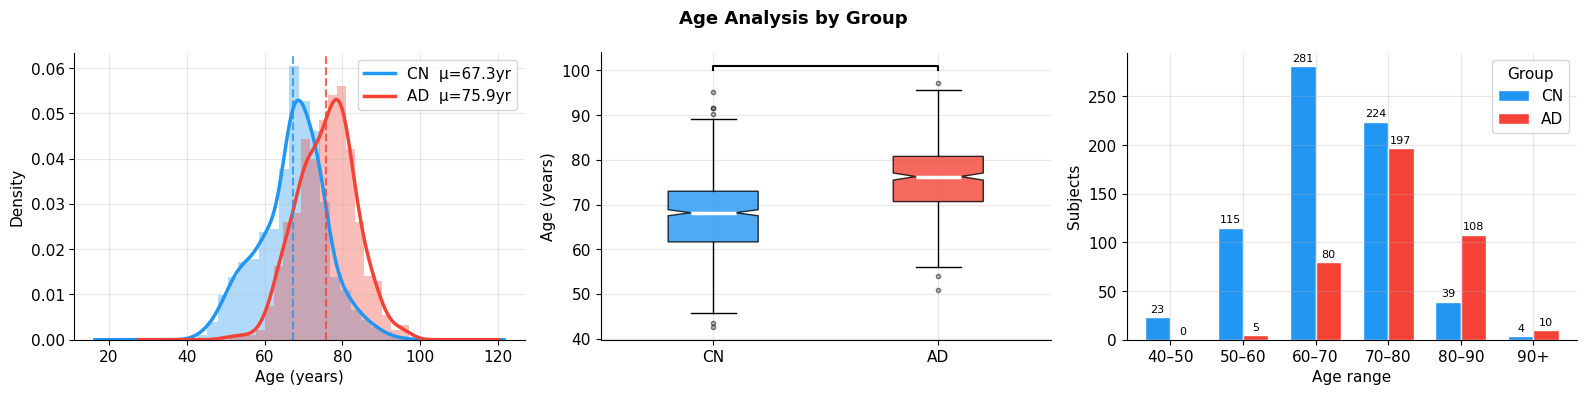

CN  Age: 67.3 ± 8.7 yr
AD  Age: 75.9 ± 7.4 yr  (Δ=8.6 yr)


In [6]:
t_age, p_age = stats.ttest_ind(CN['Age'], AD['Age'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Age Analysis by Group', fontsize=13, fontweight='bold')

# KDE
ax = axes[0]
for grp, color in PALETTE.items():
    data = df[df['Group']==grp]['Age']
    ax.hist(data, bins=20, alpha=0.35, color=color, density=True)
    data.plot.kde(ax=ax, color=color, lw=2.5, label=f'{grp}  μ={data.mean():.1f}yr')
ax.axvline(CN['Age'].mean(), color=PALETTE['CN'], ls='--', lw=1.5, alpha=0.8)
ax.axvline(AD['Age'].mean(), color=PALETTE['AD'], ls='--', lw=1.5, alpha=0.8)
ax.set_xlabel('Age (years)'); ax.set_ylabel('Density'); ax.legend()

# Boxplot
ax = axes[1]
bp = ax.boxplot([CN['Age'].values, AD['Age'].values],
                patch_artist=True, notch=True, widths=0.4,
                medianprops=dict(color='white', lw=2.5),
                flierprops=dict(marker='o', markerfacecolor='grey', markersize=3, alpha=0.5))
for patch, color in zip(bp['boxes'], [PALETTE['CN'], PALETTE['AD']]):
    patch.set_facecolor(color); patch.set_alpha(0.8)
y = max(CN['Age'].max(), AD['Age'].max()) + 3
ax.plot([1,1,2,2], [y,y+1,y+1,y], lw=1.5, color='black')
ax.set_xticks([1,2]); ax.set_xticklabels(['CN','AD'])
ax.set_ylabel('Age (years)')

# Age bins
ax = axes[2]
bin_edges  = [40,50,60,70,80,90,100]
bin_labels = ['40–50','50–60','60–70','70–80','80–90','90+']
df['AgeBin'] = pd.cut(df['Age'], bins=bin_edges, labels=bin_labels, right=False)
age_grp = (df.groupby(['AgeBin','Group'], observed=True)
             .size().unstack(fill_value=0).reindex(columns=['CN','AD']))
age_grp.plot(kind='bar', ax=ax, color=[PALETTE['CN'],PALETTE['AD']],
             edgecolor='white', width=0.7)
for c in ax.containers: ax.bar_label(c, fontsize=8, padding=2)
ax.set_xlabel('Age range'); ax.set_ylabel('Subjects')
ax.tick_params(axis='x', rotation=0); ax.legend(title='Group')

plt.tight_layout()
plt.show()

print(f'CN  Age: {CN["Age"].mean():.1f} ± {CN["Age"].std():.1f} yr')
print(f'AD  Age: {AD["Age"].mean():.1f} ± {AD["Age"].std():.1f} yr  (Δ={AD["Age"].mean()-CN["Age"].mean():.1f} yr)')



## 6. Sex distribution

Sex distribution differs significantly between groups (χ²=14.05, p<0.001):
CN contains more women (59.2%) than AD (47.3%). Sex is used for stratification
in train/val/test splits but not as a predictive feature (Section 6.3.1).
This analysis also aligns with **SDG 5 (Gender Equality)**.


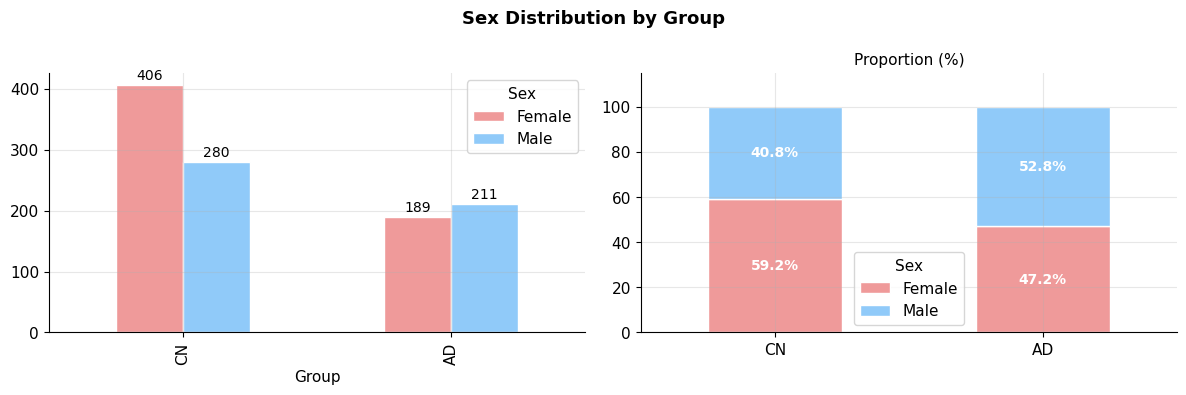

Sex    Female  Male   All
Group                    
AD        189   211   400
CN        406   280   686
All       595   491  1086


In [7]:
chi2, p_sex, *_ = stats.chi2_contingency(pd.crosstab(df['Group'], df['Sex']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Sex Distribution by Group', fontsize=13, fontweight='bold')

sex_grp = (df.groupby(['Group','Sex']).size()
             .unstack(fill_value=0).reindex(['CN','AD']))

# Counts
sex_grp.plot(kind='bar', ax=axes[0], color=['#EF9A9A','#90CAF9'],
             edgecolor='white', width=0.5)
for c in axes[0].containers: axes[0].bar_label(c, fontsize=10, padding=2)
axes[0].legend(title='Sex')

# Stacked %
sex_pct = sex_grp.div(sex_grp.sum(axis=1), axis=0) * 100
sex_pct.plot(kind='bar', stacked=True, ax=axes[1],
             color=['#EF9A9A','#90CAF9'], edgecolor='white', width=0.5)
for c in axes[1].containers:
    lbls = [f'{v:.1f}%' if v > 5 else '' for v in c.datavalues]
    axes[1].bar_label(c, labels=lbls, label_type='center',
                      fontsize=10, fontweight='bold', color='white')
axes[1].set_title('Proportion (%)', fontsize=11)
axes[1].set_xlabel(''); axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylim(0, 115); axes[1].legend(title='Sex')

plt.tight_layout()
plt.show()

print(pd.crosstab(df['Group'], df['Sex'], margins=True).to_string())


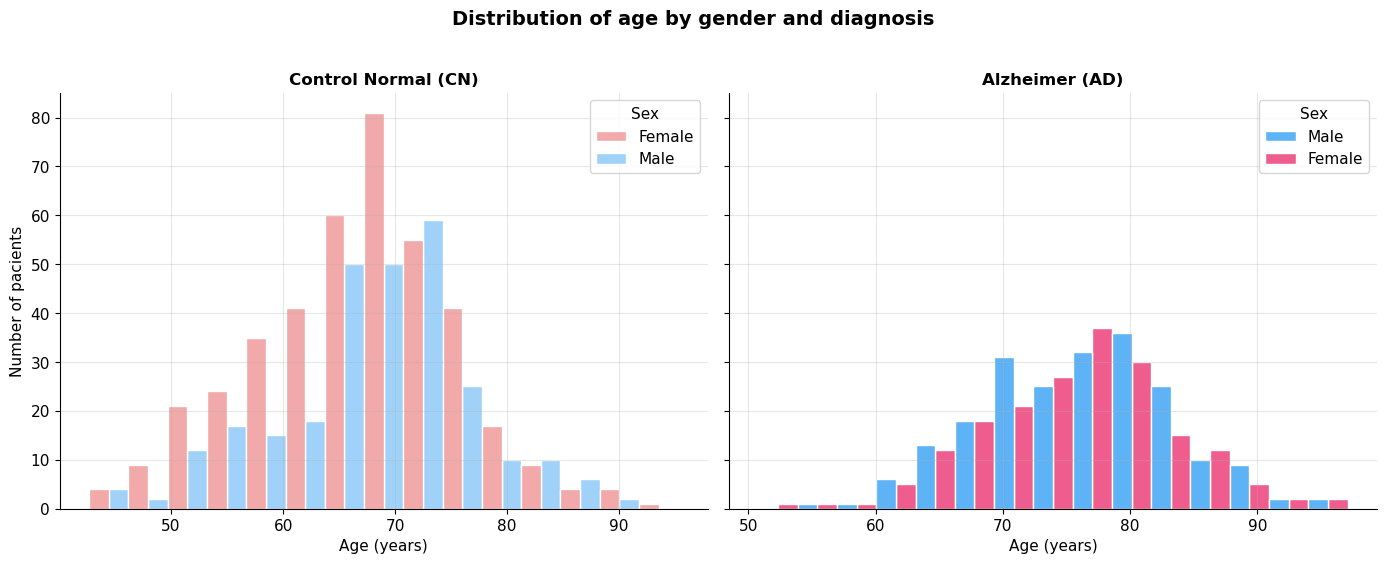

In [8]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

df = pd.read_csv('OASIS3_metadata_final.csv')
df['Group'] = df['DEMENTED'].map({0: 'CN', 1: 'AD'})
df['Sex']   = df['Gender'].map({1: 'Male', 2: 'Female'})


fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
fig.suptitle('Distribution of age by gender and diagnosis', fontsize=14, fontweight='bold', y=1.02)

# --- Histogram (CN) ---
sns.histplot(
    data=df[df['Group'] == 'CN'],
    x='Age',
    hue='Sex',
    multiple='dodge',        
    bins=15,                 
    palette={'Male': '#90CAF9', 'Female': '#EF9A9A'},  
    edgecolor='white',
    alpha=0.85,
    ax=axes[0]
)
axes[0].set_title('Control Normal (CN)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of pacients')

# --- Histogram (AD) ---
sns.histplot(
    data=df[df['Group'] == 'AD'],
    x='Age',
    hue='Sex',
    multiple='dodge',        
    bins=15,
    palette={'Male': '#42A5F5', 'Female': '#EC407A'},  
    edgecolor='white',
    alpha=0.85,
    ax=axes[1]
)
axes[1].set_title('Alzheimer (AD)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 7. Education

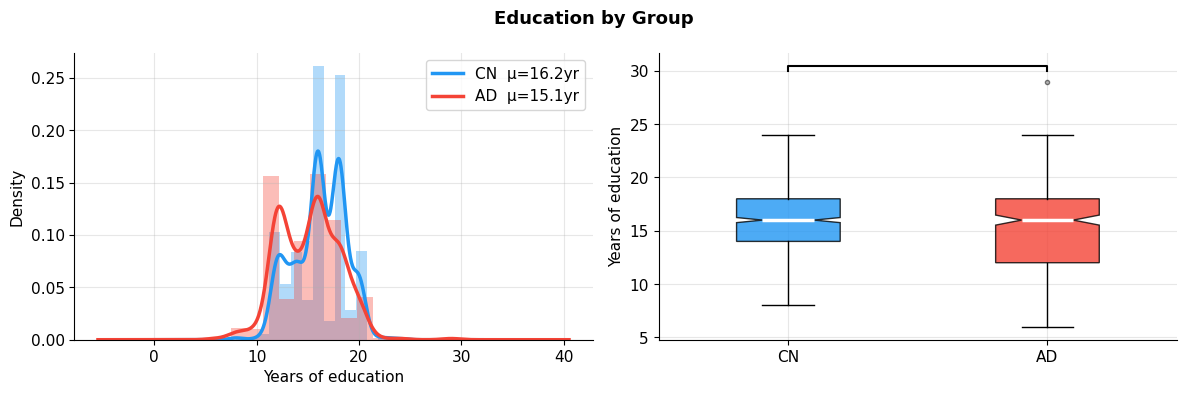

CN  Education: 16.2 ± 2.5 yr
AD  Education: 15.1 ± 2.9 yr
Welch t-test: t=6.31, p=0.000


In [9]:
t_edu, p_edu = stats.ttest_ind(CN['Education'], AD['Education'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Education by Group', fontsize=13, fontweight='bold')

# KDE
ax = axes[0]
for grp, color in PALETTE.items():
    data = df[df['Group']==grp]['Education']
    ax.hist(data, bins=15, alpha=0.35, color=color, density=True)
    data.plot.kde(ax=ax, color=color, lw=2.5, label=f'{grp}  μ={data.mean():.1f}yr')
ax.set_xlabel('Years of education'); ax.set_ylabel('Density'); ax.legend()

# Boxplot
ax = axes[1]
bp = ax.boxplot([CN['Education'].values, AD['Education'].values],
                patch_artist=True, notch=True, widths=0.4,
                medianprops=dict(color='white', lw=2.5),
                flierprops=dict(marker='o', markerfacecolor='grey', markersize=3, alpha=0.5))
for patch, color in zip(bp['boxes'], [PALETTE['CN'], PALETTE['AD']]):
    patch.set_facecolor(color); patch.set_alpha(0.8)
y = max(CN['Education'].max(), AD['Education'].max()) + 1
ax.plot([1,1,2,2], [y,y+0.5,y+0.5,y], lw=1.5, color='black')
ax.set_xticks([1,2]); ax.set_xticklabels(['CN','AD'])
ax.set_ylabel('Years of education')

plt.tight_layout()
plt.show()

print(f'CN  Education: {CN["Education"].mean():.1f} ± {CN["Education"].std():.1f} yr')
print(f'AD  Education: {AD["Education"].mean():.1f} ± {AD["Education"].std():.1f} yr')
print(f'Welch t-test: t={t_edu:.2f}, p={p_edu:.3f}')


## 8. Correlation matrix

Age shows the strongest correlation with diagnosis (r = 0.447), confirming it is
the dominant confound. Education shows a moderate negative correlation (r = −0.188).


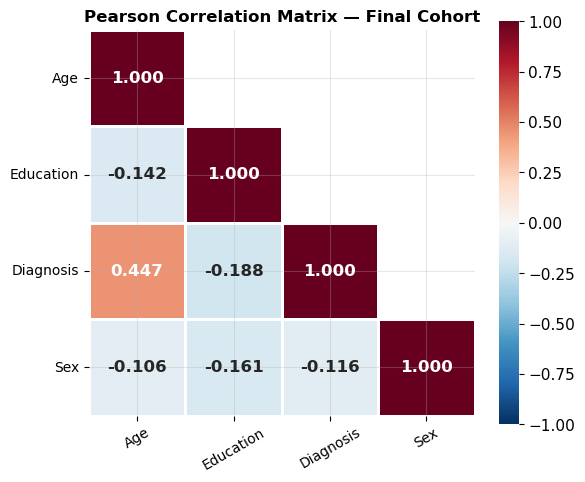

Correlations with Diagnosis:
  Age         : r = +0.447
  Education   : r = -0.188
  Gender      : r = -0.116


In [10]:
corr = df[['Age','Education','DEMENTED','Gender']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, mask=mask,
            linewidths=1, linecolor='white', square=True, ax=ax,
            xticklabels=['Age','Education','Diagnosis','Sex'],
            yticklabels=['Age','Education','Diagnosis','Sex'],
            annot_kws={'size':12,'weight':'bold'})
ax.set_title('Pearson Correlation Matrix — Final Cohort', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=30, labelsize=10)
ax.tick_params(axis='y', rotation=0, labelsize=10)
plt.tight_layout()
plt.savefig('fig_final_correlation.png', dpi=DPI, bbox_inches='tight')
plt.show()

print('Correlations with Diagnosis:')
for v in ['Age','Education','Gender']:
    print(f'  {v:12s}: r = {corr.loc[v,"DEMENTED"]:+.3f}')


## 9. Demographic summary table

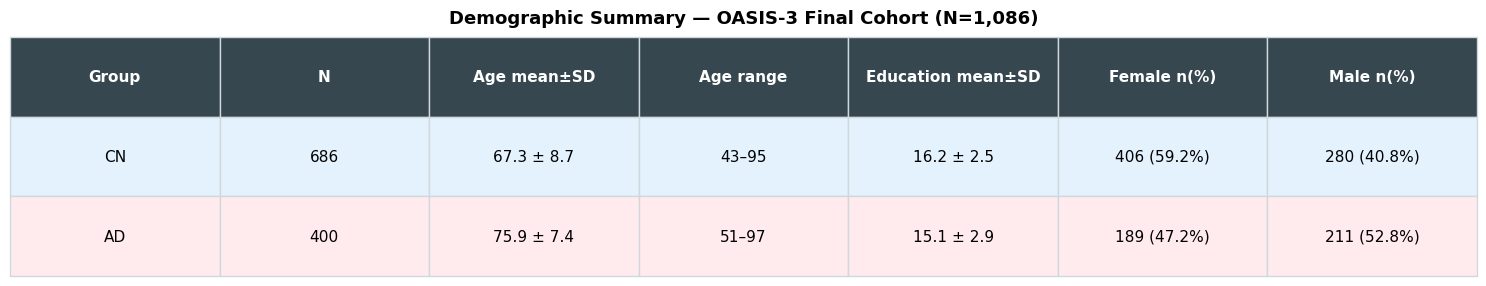

In [11]:
t_age, p_age = stats.ttest_ind(CN['Age'], AD['Age'])
t_edu, p_edu = stats.ttest_ind(CN['Education'], AD['Education'])
chi2, p_sex, *_ = stats.chi2_contingency(pd.crosstab(df['Group'], df['Sex']))

rows = []
for grp in ['CN', 'AD']:
    sub = df[df['Group'] == grp]; n = len(sub)
    n_f = (sub['Sex'] == 'Female').sum()
    n_m = (sub['Sex'] == 'Male').sum()
    rows.append([
        grp, str(n),
        f"{sub['Age'].mean():.1f} ± {sub['Age'].std():.1f}",
        f"{sub['Age'].min():.0f}–{sub['Age'].max():.0f}",
        f"{sub['Education'].mean():.1f} ± {sub['Education'].std():.1f}",
        f"{n_f} ({100*n_f/n:.1f}%)",
        f"{n_m} ({100*n_m/n:.1f}%)",
    ])

cols = ['Group','N','Age mean±SD','Age range',
        'Education mean±SD','Female n(%)','Male n(%)']

fig, ax = plt.subplots(figsize=(15, 3))
ax.axis('off')
table = ax.table(cellText=rows, colLabels=cols,
                 cellLoc='center', loc='center', bbox=[0,0,1,1])
table.auto_set_font_size(False); table.set_fontsize(11)
ROW_BG = {0:'#37474F', 1:'#E3F2FD', 2:'#FFEBEE', 3:'#ECEFF1'}
for (r,c), cell in table.get_celld().items():
    cell.set_edgecolor('#CFD8DC')
    cell.set_facecolor(ROW_BG.get(r,'white'))
    if r == 0: cell.set_text_props(color='white', fontweight='bold')
ax.set_title('Demographic Summary — OASIS-3 Final Cohort (N=1,086)',
             fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


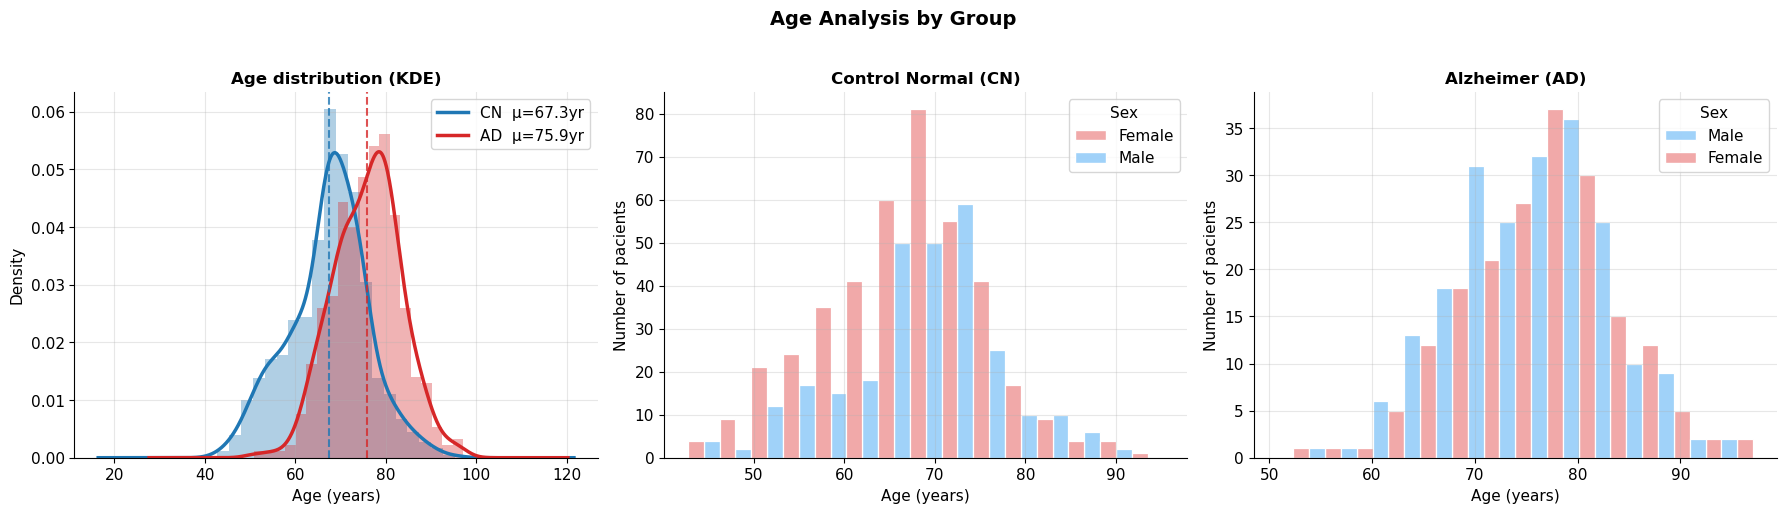

In [16]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

# --- Data ---
df = pd.read_csv('OASIS3_metadata_final.csv')
df['Group'] = df['DEMENTED'].map({0: 'CN', 1: 'AD'})
df['Sex']   = df['Gender'].map({1: 'Male', 2: 'Female'})

CN = df[df['Group'] == 'CN']
AD = df[df['Group'] == 'AD']
PALETTE = {'CN': '#1f77b4', 'AD': '#d62728'}

t_age, p_age = stats.ttest_ind(CN['Age'], AD['Age'])

# --- Figure: 1 row, 3 columns ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Age Analysis by Group', fontsize=14, fontweight='bold', y=1.02)

# --- Plot 1: KDE ---
ax = axes[0]
for grp, color in PALETTE.items():
    data = df[df['Group'] == grp]['Age']
    ax.hist(data, bins=20, alpha=0.35, color=color, density=True)
    data.plot.kde(ax=ax, color=color, lw=2.5, label=f'{grp}  μ={data.mean():.1f}yr')
ax.axvline(CN['Age'].mean(), color=PALETTE['CN'], ls='--', lw=1.5, alpha=0.8)
ax.axvline(AD['Age'].mean(), color=PALETTE['AD'], ls='--', lw=1.5, alpha=0.8)
ax.set_title('Age distribution (KDE)', fontsize=12, fontweight='bold')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.legend()

# --- Plot 2: Histogram (CN) ---
sns.histplot(
    data=CN,
    x='Age',
    hue='Sex',
    multiple='dodge',
    bins=15,
    palette={'Male': '#90CAF9', 'Female': '#EF9A9A'},
    edgecolor='white',
    alpha=0.85,
    ax=axes[1]
)
axes[1].set_title('Control Normal (CN)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Number of pacients')

# --- Plot 3: Histogram (AD) ---
sns.histplot(
    data=AD,
    x='Age',
    hue='Sex',
    multiple='dodge',
    bins=15,
    palette={'Male': '#90CAF9', 'Female': '#EF9A9A'},
    edgecolor='white',
    alpha=0.85,
    ax=axes[2]
)
axes[2].set_title('Alzheimer (AD)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Age (years)')
axes[2].set_ylabel('Number of pacients')

plt.tight_layout()
plt.show()